# CardioTwin EDA and Feature Analysis

IIT Multimodal AI Hackathon 2026 Track A.

This notebook studies predictive structure for CAD, LAD stenosis, LCX stenosis, and RCA stenosis.
It does not train or tune final models, use SMOTE/synthetic augmentation, modify raw data, globally
select/drop features from target relationships, or use one target as a predictor for another.

Because the dataset has only 303 patients and 55 predictors, all supervised analyses are explicitly
exploratory and must not be used outside cross-validation for final model decisions.

In [1]:
from __future__ import annotations

import itertools
import json
import math
import random
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OrdinalEncoder

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 220)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", "{:.4f}".format)
plt.style.use("seaborn-v0_8-whitegrid")

FORBIDDEN_COLUMNS = {"LAD", "LCX", "RCA", "Cath"}
TARGETS = ["cad", "lad", "lcx", "rca"]


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "ml" / "data" / "processed").exists():
            return candidate
        if candidate.name == "ml" and (candidate / "data" / "processed").exists():
            return candidate.parent
    raise FileNotFoundError("Could not locate project root containing ml/data/processed.")


PROJECT_ROOT = find_project_root()
ML_DIR = PROJECT_ROOT / "ml"
PROCESSED_DIR = ML_DIR / "data" / "processed"
EDA_DIR = ML_DIR / "artifacts" / "metrics" / "eda"
EDA_DIR.mkdir(parents=True, exist_ok=True)

X = pd.read_csv(PROCESSED_DIR / "features_clean.csv")
y = pd.read_csv(PROCESSED_DIR / "targets_clean.csv")
feature_metadata = pd.read_csv(PROCESSED_DIR / "feature_metadata.csv")

numeric_features = feature_metadata.loc[feature_metadata["feature_type"].eq("numeric"), "feature"].tolist()
categorical_features = feature_metadata.loc[~feature_metadata["feature_type"].eq("numeric"), "feature"].tolist()

assert len(X) == len(y) == 303
assert list(y.columns) == TARGETS
assert X.index.equals(y.index)
assert FORBIDDEN_COLUMNS.isdisjoint(X.columns)
assert X.columns.is_unique
assert not any(str(c).lower().startswith("unnamed") for c in X.columns)
assert not any(str(c).lower().startswith("unnamed") for c in y.columns)
for target in TARGETS:
    assert set(y[target].dropna().unique()).issubset({0, 1})
assert np.isfinite(X[numeric_features].apply(pd.to_numeric, errors="coerce").to_numpy()).all()
assert set(numeric_features + categorical_features) == set(X.columns)

print(f"Project root: {PROJECT_ROOT}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Numeric predictors: {len(numeric_features)}")
print(f"Categorical/binary predictors: {len(categorical_features)}")

Project root: C:\Users\samri\cod\git\IIT_Mandi\cardio-3d-ai
X shape: (303, 55)
y shape: (303, 4)
Numeric predictors: 21
Categorical/binary predictors: 34


## Reusable Functions

In [2]:
def save_table(df: pd.DataFrame, filename: str) -> Path:
    path = EDA_DIR / filename
    df.to_csv(path, index=False)
    print(f"Saved {path.relative_to(PROJECT_ROOT)}: {df.shape}")
    return path


def benjamini_hochberg(p_values: pd.Series) -> pd.Series:
    p = pd.to_numeric(p_values, errors="coerce")
    out = pd.Series(np.nan, index=p.index, dtype=float)
    valid = p.dropna()
    if valid.empty:
        return out
    order = valid.sort_values().index
    ranked = valid.loc[order].to_numpy()
    m = len(ranked)
    adjusted = ranked * m / np.arange(1, m + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    out.loc[order] = np.clip(adjusted, 0, 1)
    return out


def phi_coefficient(a: pd.Series, b: pd.Series) -> float:
    table = pd.crosstab(a, b).reindex(index=[0, 1], columns=[0, 1], fill_value=0)
    n00, n01 = table.loc[0, 0], table.loc[0, 1]
    n10, n11 = table.loc[1, 0], table.loc[1, 1]
    denom = math.sqrt((n10 + n11) * (n00 + n01) * (n01 + n11) * (n00 + n10))
    return np.nan if denom == 0 else ((n11 * n00) - (n10 * n01)) / denom


def cramers_v(contingency: pd.DataFrame) -> float:
    if contingency.empty or min(contingency.shape) < 2:
        return np.nan
    chi2, _, _, _ = stats.chi2_contingency(contingency)
    n = contingency.to_numpy().sum()
    denom = n * min(contingency.shape[0] - 1, contingency.shape[1] - 1)
    return math.sqrt(chi2 / denom) if denom > 0 else np.nan


def rank_biserial_from_u(u_stat: float, n0: int, n1: int) -> float:
    return np.nan if n0 == 0 or n1 == 0 or pd.isna(u_stat) else (2 * u_stat / (n0 * n1)) - 1


def imbalance_ratio(series: pd.Series) -> float:
    counts = series.value_counts().reindex([0, 1], fill_value=0)
    minority = counts.min()
    return np.inf if minority == 0 else float(counts.max() / minority)


def safe_point_biserial(feature: pd.Series, target: pd.Series) -> tuple[float, float]:
    x = pd.to_numeric(feature, errors="coerce")
    mask = x.notna() & target.notna()
    if mask.sum() < 3 or x[mask].nunique() < 2 or target[mask].nunique() < 2:
        return np.nan, np.nan
    r, p = stats.pointbiserialr(target[mask], x[mask])
    return float(r), float(p)


def classify_signal(abs_effect: float, fdr_p: float, mi_score: float) -> str:
    effect = 0 if pd.isna(abs_effect) else abs_effect
    fdr = 1 if pd.isna(fdr_p) else fdr_p
    mi = 0 if pd.isna(mi_score) else mi_score
    if (effect >= 0.30 and fdr <= 0.10) or mi >= 0.05:
        return "Strong exploratory signal"
    if effect >= 0.20 or fdr <= 0.20 or mi >= 0.02:
        return "Moderate exploratory signal"
    return "Weak exploratory signal"


def plot_heatmap(matrix: pd.DataFrame, title: str, figsize=(12, 10), vmin=-1, vmax=1) -> None:
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(matrix, cmap="coolwarm", vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_xticks(range(len(matrix.columns)))
    ax.set_yticks(range(len(matrix.index)))
    ax.set_xticklabels(matrix.columns, rotation=90)
    ax.set_yticklabels(matrix.index)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

## 2. Target Analysis

,target,negative_count,positive_count,negative_percent,positive_percent,imbalance_ratio_majority_to_minority
0,cad,87,216,28.7129,71.2871,2.4828
1,lad,126,177,41.5842,58.4158,1.4048
2,lcx,184,119,60.7261,39.2739,1.5462
3,rca,189,114,62.3762,37.6238,1.6579


Saved ml\artifacts\metrics\eda\target_distribution.csv: (4, 6)


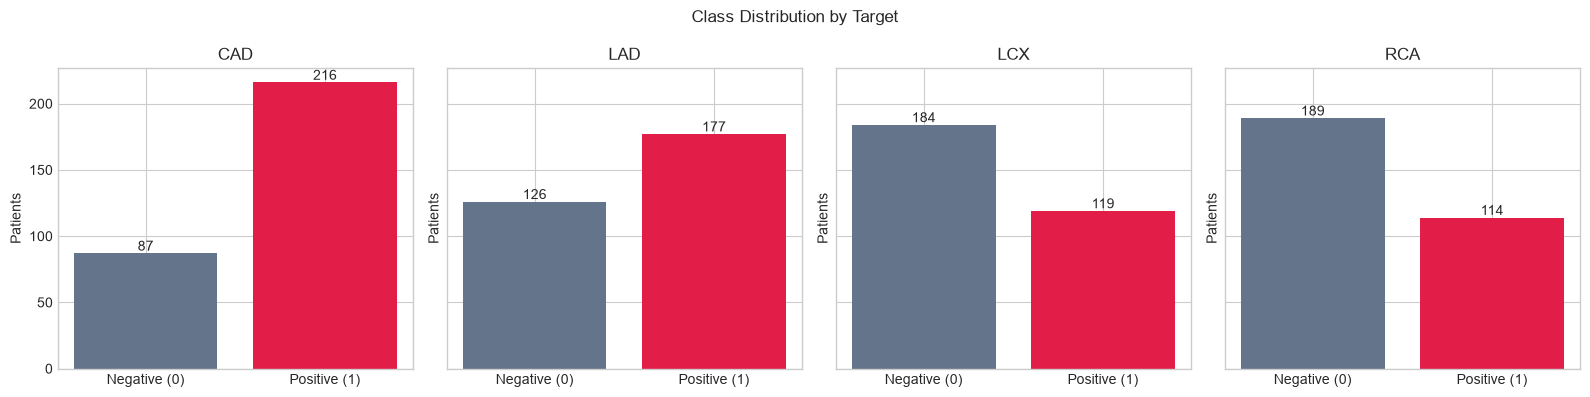

,target_1,target_2,n00,n01,n10,n11,phi_coefficient
0,cad,lad,86,1,40,176,0.7374
1,cad,lcx,87,0,97,119,0.5104
2,cad,rca,87,0,102,114,0.4929
3,lad,lcx,103,23,81,96,0.3632
4,lad,rca,99,27,90,87,0.2821
5,lcx,rca,143,41,46,73,0.3938


Saved ml\artifacts\metrics\eda\target_associations.csv: (6, 7)


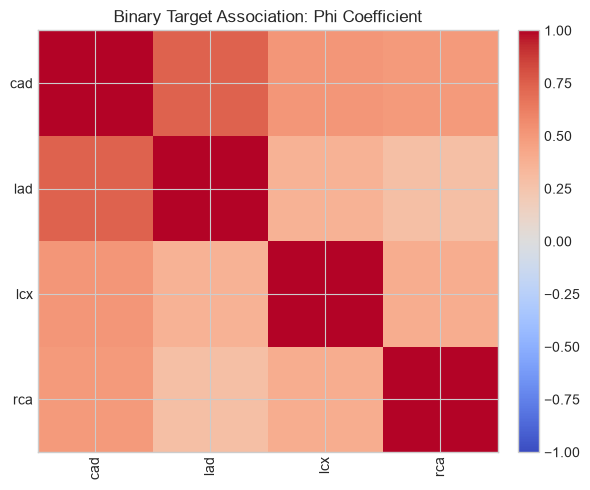

In [3]:
target_distribution = pd.DataFrame([
    {
        "target": target,
        "negative_count": int(y[target].value_counts().reindex([0, 1], fill_value=0).loc[0]),
        "positive_count": int(y[target].value_counts().reindex([0, 1], fill_value=0).loc[1]),
        "negative_percent": float(y[target].value_counts(normalize=True).reindex([0, 1], fill_value=0).loc[0] * 100),
        "positive_percent": float(y[target].value_counts(normalize=True).reindex([0, 1], fill_value=0).loc[1] * 100),
        "imbalance_ratio_majority_to_minority": imbalance_ratio(y[target]),
    }
    for target in TARGETS
])
display(target_distribution)
save_table(target_distribution, "target_distribution.csv")

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, target in zip(axes, TARGETS):
    counts = y[target].value_counts().reindex([0, 1], fill_value=0)
    ax.bar(["Negative (0)", "Positive (1)"], counts.values, color=["#64748b", "#e11d48"])
    ax.set_title(target.upper())
    ax.set_ylabel("Patients")
    for i, value in enumerate(counts.values):
        ax.text(i, value + 2, str(value), ha="center")
plt.suptitle("Class Distribution by Target")
plt.tight_layout()
plt.show()

target_assoc_rows = []
for a, b in itertools.combinations(TARGETS, 2):
    table = pd.crosstab(y[a], y[b]).reindex(index=[0, 1], columns=[0, 1], fill_value=0)
    target_assoc_rows.append({
        "target_1": a, "target_2": b,
        "n00": int(table.loc[0, 0]), "n01": int(table.loc[0, 1]),
        "n10": int(table.loc[1, 0]), "n11": int(table.loc[1, 1]),
        "phi_coefficient": phi_coefficient(y[a], y[b]),
    })
target_associations = pd.DataFrame(target_assoc_rows)
display(target_associations)
save_table(target_associations, "target_associations.csv")

phi_matrix = pd.DataFrame(np.eye(len(TARGETS)), index=TARGETS, columns=TARGETS)
for _, row in target_associations.iterrows():
    phi_matrix.loc[row["target_1"], row["target_2"]] = row["phi_coefficient"]
    phi_matrix.loc[row["target_2"], row["target_1"]] = row["phi_coefficient"]
plot_heatmap(phi_matrix, "Binary Target Association: Phi Coefficient", figsize=(6, 5))

## 3. Numerical Feature Analysis

,feature,count,mean,median,std,min,q1,q3,max,iqr,skewness,outlier_count_iqr,may_benefit_from_transformation_later
0,Age,303,58.8977,58.0000,10.3923,30.0000,51.0000,66.0000,86.0000,15.0000,0.1349,0,False
3,BMI,303,27.2483,26.7755,4.0989,18.1154,24.5144,29.4118,40.9007,4.8974,0.4342,6,False
4,BP,303,129.5545,130.0000,18.9381,90.0000,120.0000,140.0000,190.0000,20.0000,0.5726,9,False
11,BUN,303,17.5017,16.0000,6.9568,6.0000,13.0000,20.0000,52.0000,7.0000,1.8182,17,True
7,CR,303,1.0556,1.0000,0.2643,0.5000,0.9000,1.2000,2.2000,0.3000,0.9502,8,False
20,EF-TTE,303,47.2310,50.0000,8.9272,15.0000,45.0000,55.0000,60.0000,10.0000,-1.3380,15,True
12,ESR,303,19.4620,15.0000,15.9365,1.0000,9.0000,26.0000,90.0000,17.0000,1.6299,13,True
6,FBS,303,119.1848,98.0000,52.0797,62.0000,88.5000,130.0000,400.0000,41.5000,2.2764,30,True
13,HB,303,13.1535,13.2000,1.6105,8.9000,12.2000,14.2000,17.6000,2.0000,-0.1786,7,False
10,HDL,303,40.2340,39.0000,10.5591,15.9000,33.5000,45.5000,111.0000,12.0000,1.4606,6,True


,feature,count,mean,median,std,min,q1,q3,max,iqr,skewness,outlier_count_iqr,may_benefit_from_transformation_later
8,TG,303,150.3432,122.0000,97.9595,37.0000,90.0000,177.0000,1050.0000,87.0000,3.7820,16,True
19,PLT,303,221.4884,210.0000,60.7962,25.0000,183.5000,250.0000,742.0000,66.5000,2.5890,11,True
6,FBS,303,119.1848,98.0000,52.0797,62.0000,88.5000,130.0000,400.0000,41.5000,2.2764,30,True
11,BUN,303,17.5017,16.0000,6.9568,6.0000,13.0000,20.0000,52.0000,7.0000,1.8182,17,True
12,ESR,303,19.4620,15.0000,15.9365,1.0000,9.0000,26.0000,90.0000,17.0000,1.6299,13,True
10,HDL,303,40.2340,39.0000,10.5591,15.9000,33.5000,45.5000,111.0000,12.0000,1.4606,6,True
16,WBC,303,7562.0462,7100.0000,2413.7393,3700.0000,5800.0000,8800.0000,18000.0000,3000.0000,1.3877,9,True
20,EF-TTE,303,47.2310,50.0000,8.9272,15.0000,45.0000,55.0000,60.0000,10.0000,-1.3380,15,True
5,PR,303,75.1419,70.0000,8.9118,50.0000,70.0000,80.0000,110.0000,10.0000,1.0789,13,True


Saved ml\artifacts\metrics\eda\numeric_summary.csv: (21, 13)


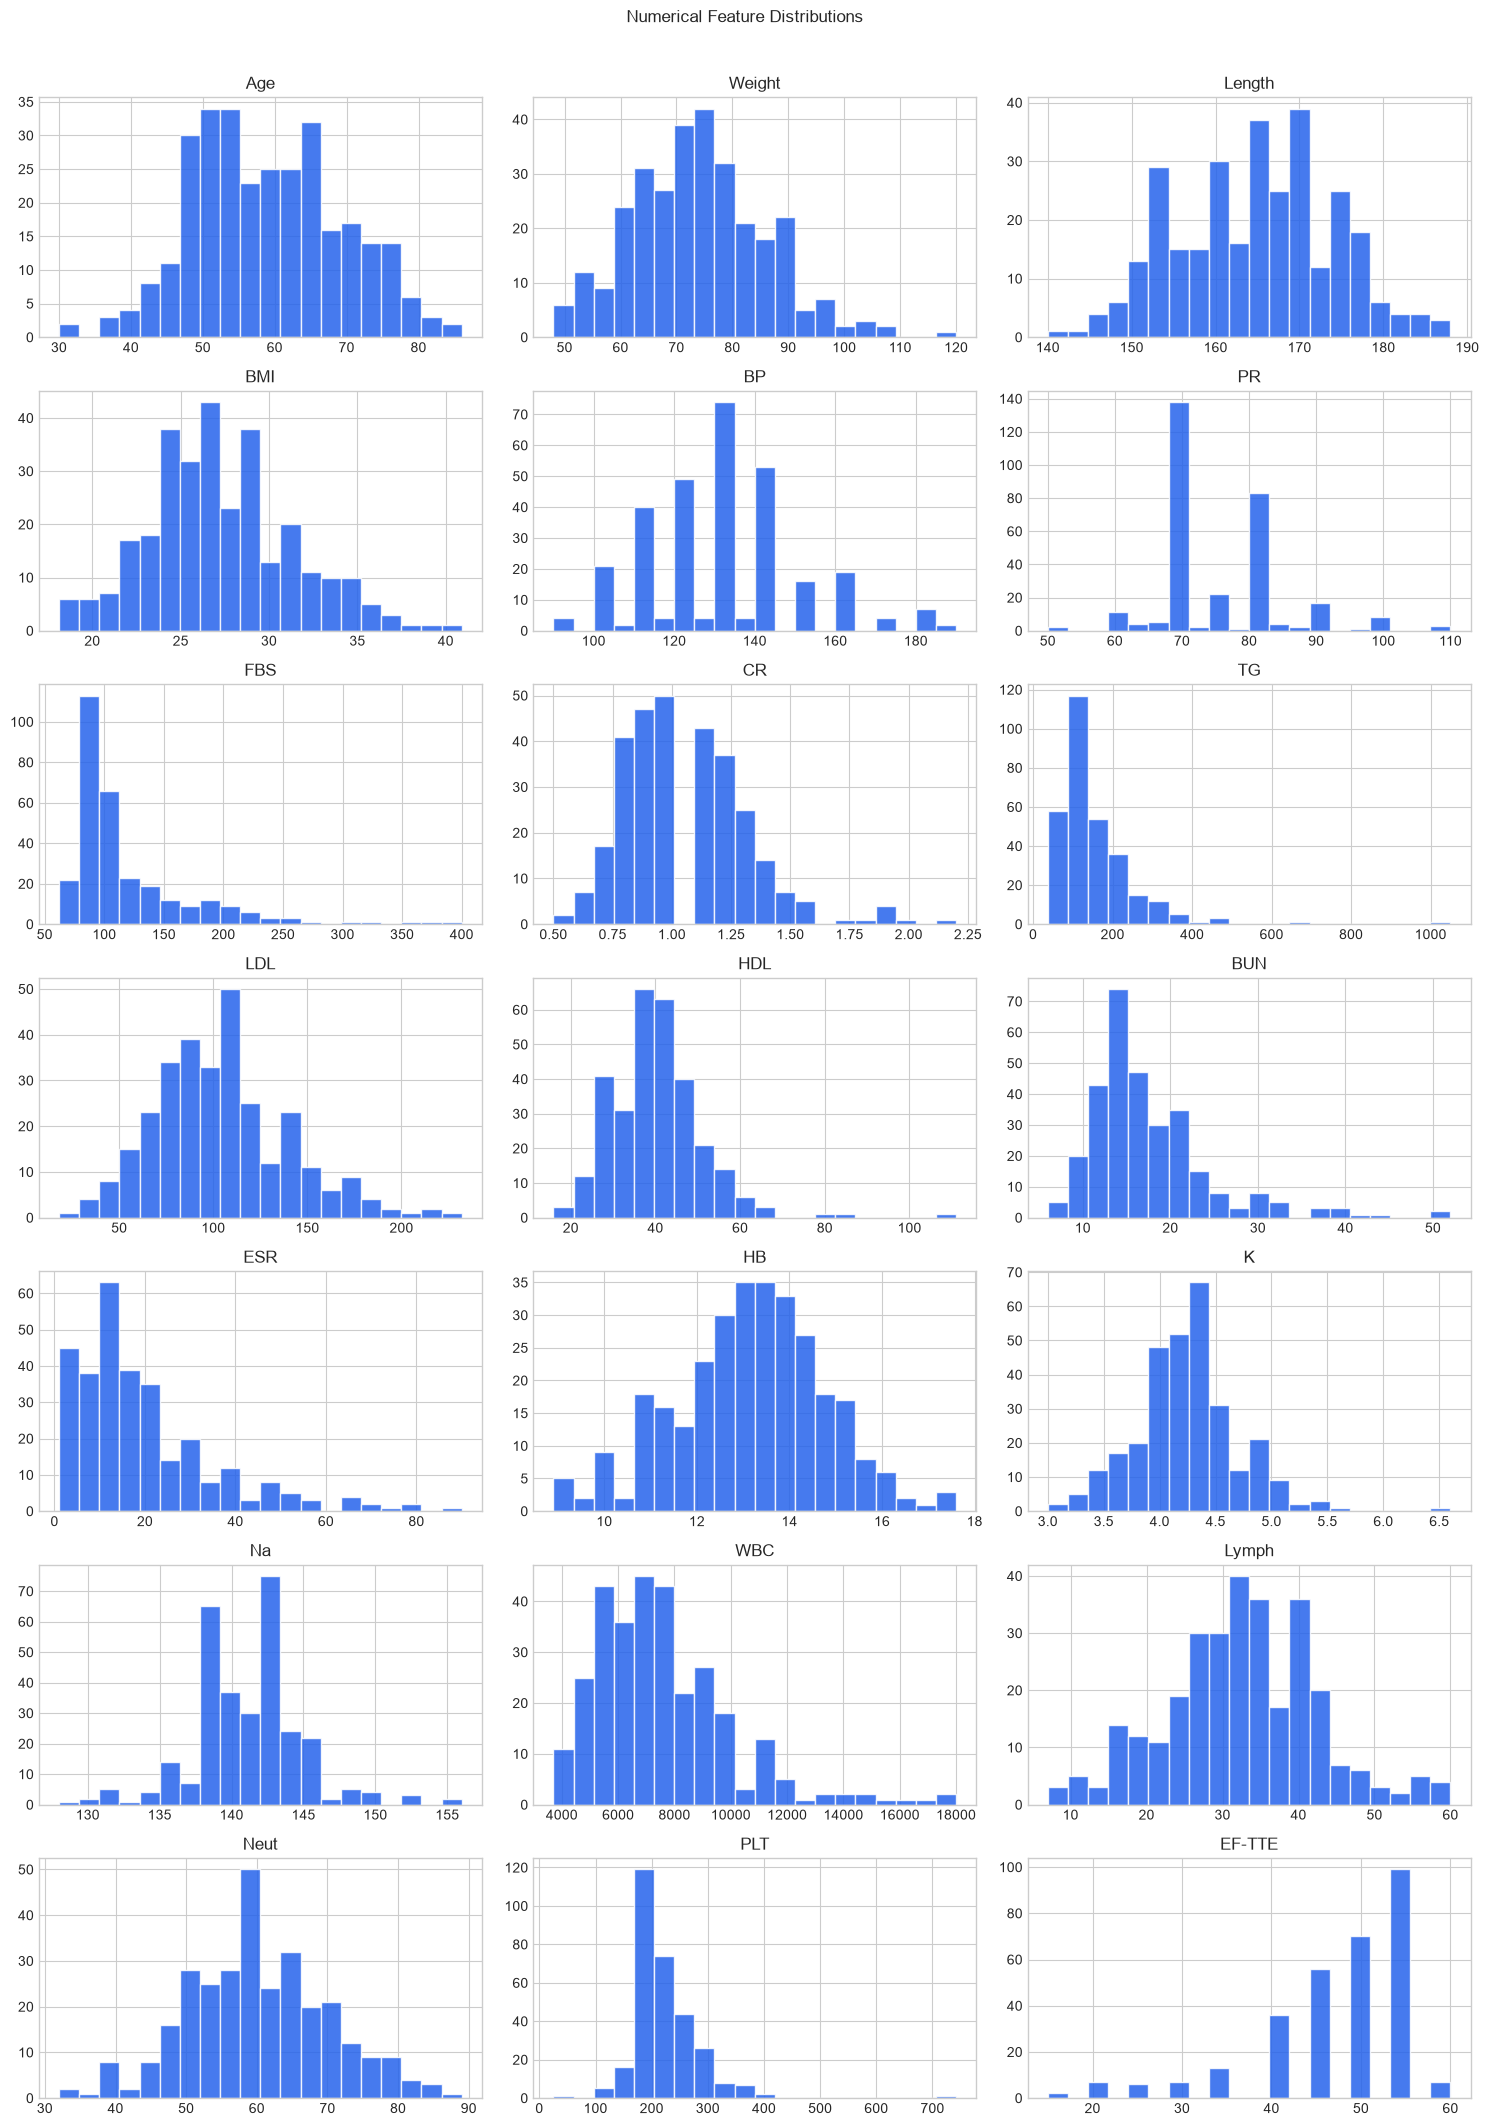

C:\Users\samri\AppData\Local\Temp\ipykernel_35564\3019265281.py:35: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(numeric_data[feature].dropna(), vert=False, patch_artist=True)
C:\Users\samri\AppData\Local\Temp\ipykernel_35564\3019265281.py:35: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(numeric_data[feature].dropna(), vert=False, patch_artist=True)
C:\Users\samri\AppData\Local\Temp\ipykernel_35564\3019265281.py:35: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(numeric_data[feature].dropna(), vert=False, patch_artist=True)
C:\Users\samri\AppData\Local\Temp\ipykernel_35564\3019265281.py:35: MatplotlibDeprecationWarning:

C:\Users\samri\AppData\Local\Temp\ipykernel_35564\3019265281.py:35: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(numeric_data[feature].dropna(), vert=False, patch_artist=True)
C:\Users\samri\AppData\Local\Temp\ipykernel_35564\3019265281.py:35: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(numeric_data[feature].dropna(), vert=False, patch_artist=True)
C:\Users\samri\AppData\Local\Temp\ipykernel_35564\3019265281.py:35: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(numeric_data[feature].dropna(), vert=False, patch_artist=True)
C:\Users\samri\AppData\Local\Temp\ipykernel_35564\3019265281.py:35: MatplotlibDeprecationWarning:

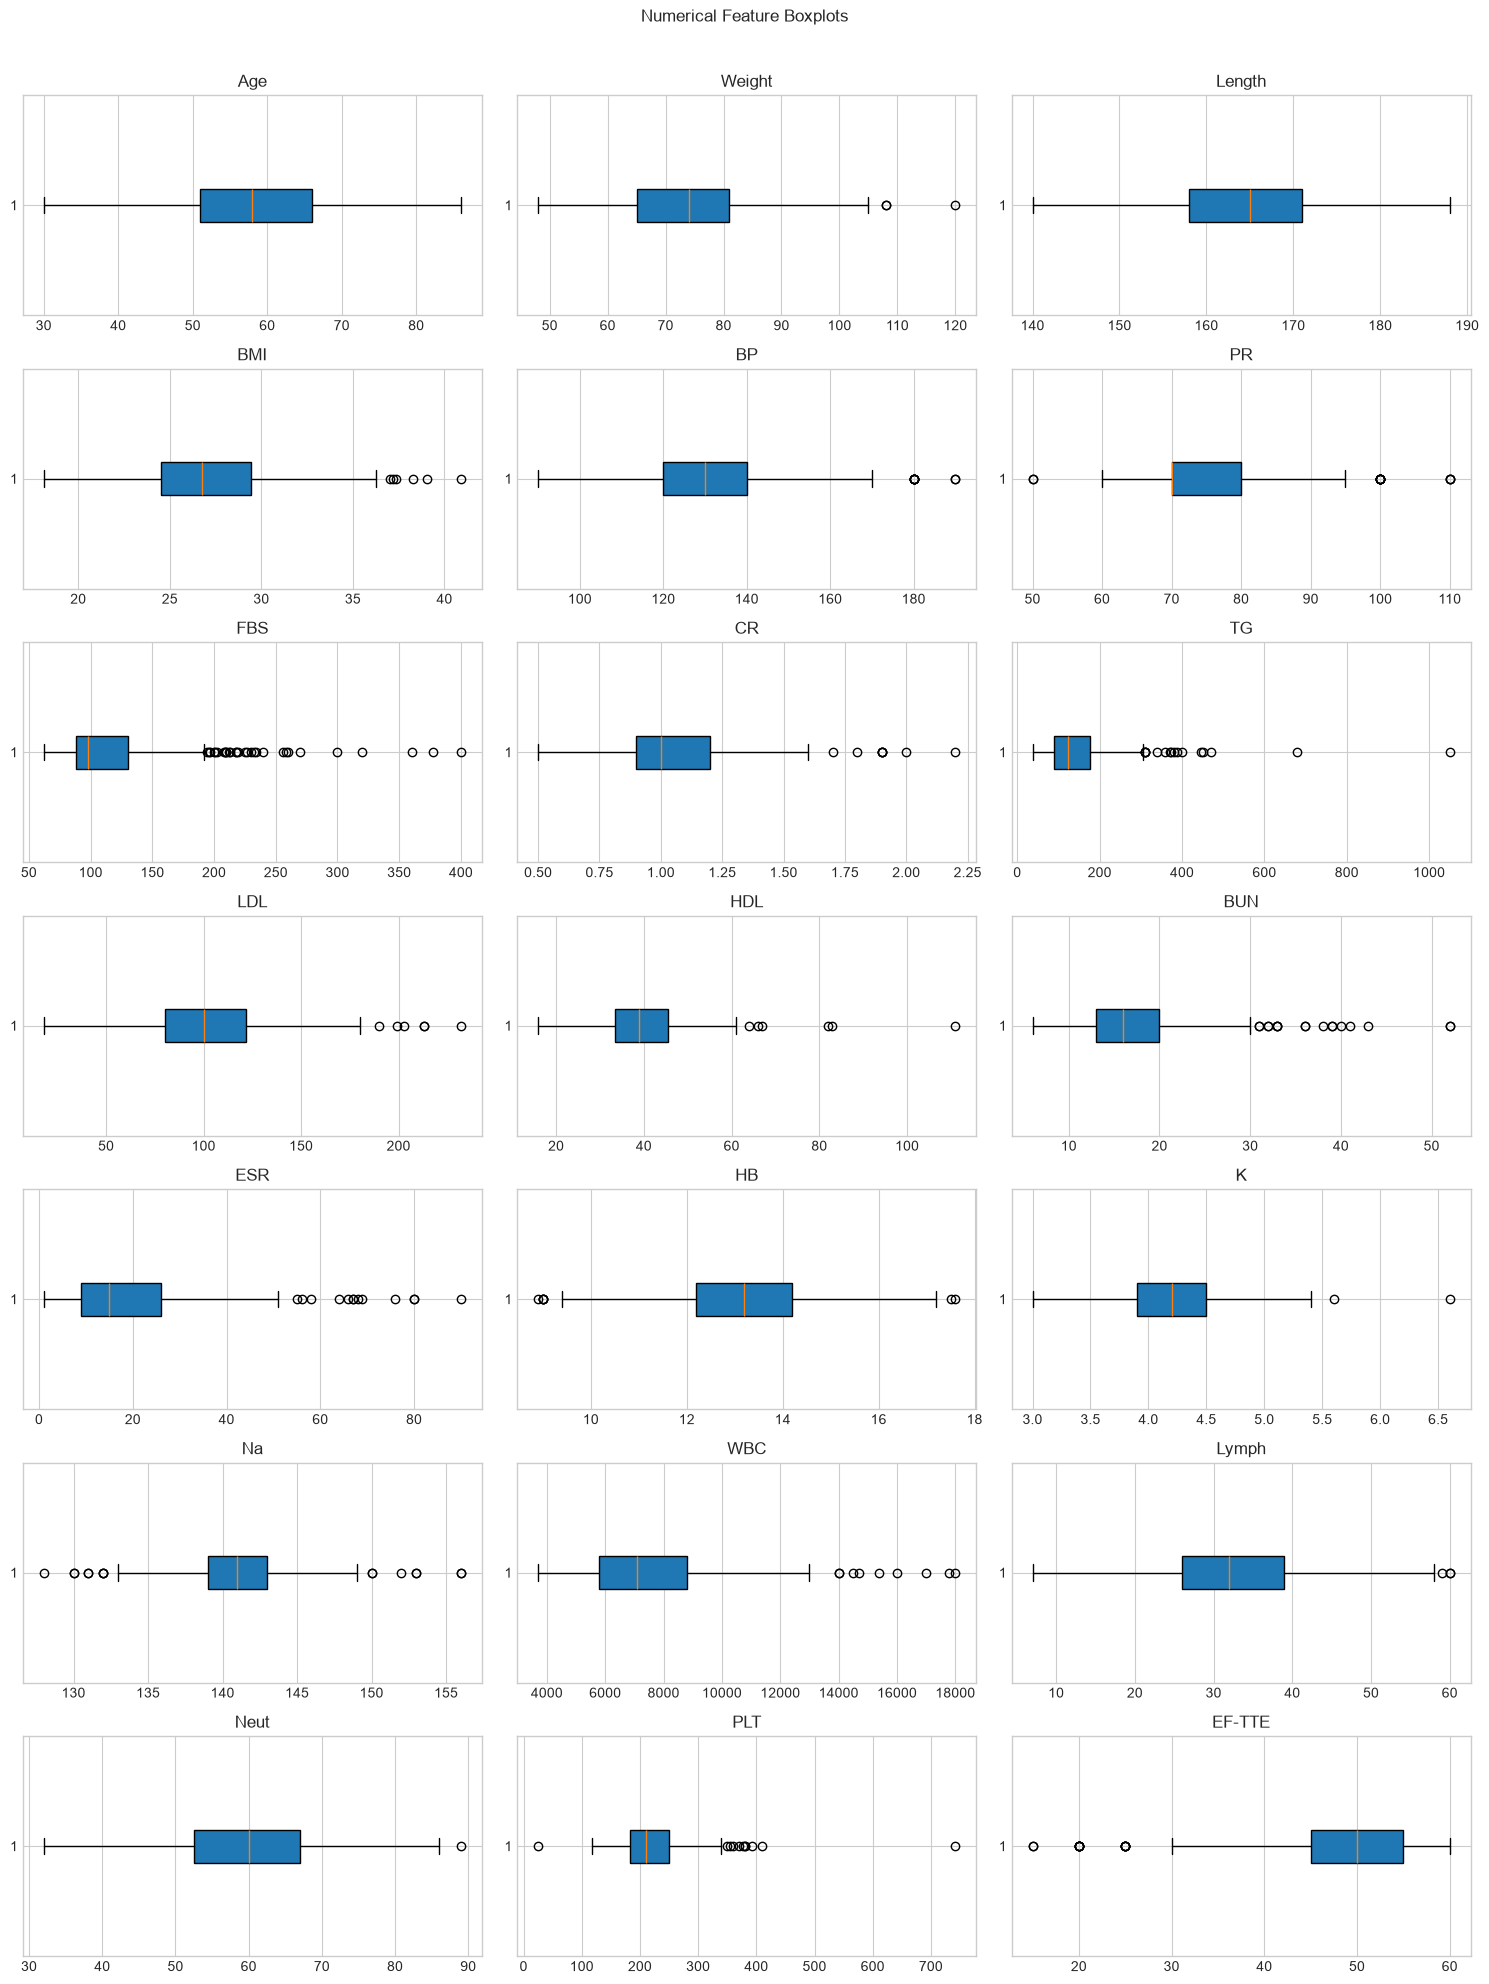

In [4]:
numeric_data = X[numeric_features].apply(pd.to_numeric, errors="coerce")
numeric_rows = []
for feature in numeric_features:
    s = numeric_data[feature].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    skewness = float(s.skew()) if len(s) > 2 else np.nan
    numeric_rows.append({
        "feature": feature, "count": int(s.count()), "mean": s.mean(), "median": s.median(),
        "std": s.std(), "min": s.min(), "q1": q1, "q3": q3, "max": s.max(), "iqr": iqr,
        "skewness": skewness, "outlier_count_iqr": int(((s < lower) | (s > upper)).sum()),
        "may_benefit_from_transformation_later": abs(skewness) >= 1 if pd.notna(skewness) else False,
    })
numeric_summary = pd.DataFrame(numeric_rows).sort_values("feature")
display(numeric_summary)
display(numeric_summary[numeric_summary["may_benefit_from_transformation_later"]].sort_values("skewness", key=lambda s: s.abs(), ascending=False))
save_table(numeric_summary, "numeric_summary.csv")

n_cols, n_rows = 3, math.ceil(len(numeric_features) / 3)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3))
axes = np.array(axes).reshape(-1)
for ax, feature in zip(axes, numeric_features):
    ax.hist(numeric_data[feature].dropna(), bins=20, color="#2563eb", alpha=0.85, edgecolor="white")
    ax.set_title(feature)
for ax in axes[len(numeric_features):]:
    ax.axis("off")
plt.suptitle("Numerical Feature Distributions", y=1.01)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 2.8))
axes = np.array(axes).reshape(-1)
for ax, feature in zip(axes, numeric_features):
    ax.boxplot(numeric_data[feature].dropna(), vert=False, patch_artist=True)
    ax.set_title(feature)
for ax in axes[len(numeric_features):]:
    ax.axis("off")
plt.suptitle("Numerical Feature Boxplots", y=1.01)
plt.tight_layout()
plt.show()

## 4. Categorical Feature Analysis

In [5]:
categorical_rows, rare_rows, near_constant_rows = [], [], []
for feature in categorical_features:
    s = X[feature].astype("string").fillna("<MISSING>")
    counts = s.value_counts(dropna=False)
    percents = s.value_counts(normalize=True, dropna=False) * 100
    top_ratio = float(percents.iloc[0] / 100) if len(percents) else np.nan
    if top_ratio >= 0.95 or s.nunique(dropna=False) <= 1:
        near_constant_rows.append({
            "feature": feature,
            "unique_count": int(s.nunique(dropna=False)),
            "top_category": str(counts.index[0]) if len(counts) else np.nan,
            "top_category_percent": float(percents.iloc[0]) if len(percents) else np.nan,
        })
    for category, count in counts.items():
        percent = float(percents.loc[category])
        row = {"feature": feature, "category": str(category), "count": int(count), "percent": percent, "is_rare_lt_5_percent": percent < 5}
        categorical_rows.append(row)
        if percent < 5:
            rare_rows.append(row)

categorical_summary = pd.DataFrame(categorical_rows).sort_values(["feature", "count"], ascending=[True, False])
rare_categories = pd.DataFrame(rare_rows).sort_values(["percent", "feature"]) if rare_rows else pd.DataFrame(columns=categorical_summary.columns)
near_constant_features = pd.DataFrame(near_constant_rows).sort_values("top_category_percent", ascending=False) if near_constant_rows else pd.DataFrame(columns=["feature", "unique_count", "top_category", "top_category_percent"])
display(categorical_summary)
display(rare_categories)
display(near_constant_features)
save_table(categorical_summary, "categorical_summary.csv")

,feature,category,count,percent,is_rare_lt_5_percent
18,Airway disease,N,292,96.3696,False
19,Airway disease,Y,11,3.6304,True
44,Atypical,N,210,69.3069,False
45,Atypical,Y,93,30.6931,False
63,BBB,N,282,93.0693,False
64,BBB,LBBB,13,4.2904,True
65,BBB,RBBB,8,2.6403,True
22,CHF,N,302,99.6700,False
23,CHF,Y,1,0.3300,True
14,CRF,N,297,98.0198,False


,feature,category,count,percent,is_rare_lt_5_percent
5,CHF,Y,1,0.3300,True
10,Function Class,1,1,0.3300,True
11,LowTH Ang,Y,2,0.6601,True
2,CVA,Y,5,1.6502,True
7,Weak Peripheral Pulse,Y,5,1.6502,True
1,CRF,Y,6,1.9802,True
4,Thyroid Disease,Y,7,2.3102,True
15,BBB,RBBB,8,2.6403,True
9,Diastolic Murmur,Y,9,2.9703,True
13,Poor R Progression,Y,9,2.9703,True


,feature,unique_count,top_category,top_category_percent
10,Exertional CP,1,N,100.0000
5,CHF,2,N,99.6700
11,LowTH Ang,2,N,99.3399
7,Weak Peripheral Pulse,2,N,98.3498
2,CVA,2,N,98.3498
1,CRF,2,N,98.0198
4,Thyroid Disease,2,N,97.6898
9,Diastolic Murmur,2,N,97.0297
13,Poor R Progression,2,N,97.0297
0,EX-Smoker,2,0,96.6997


Saved ml\artifacts\metrics\eda\categorical_summary.csv: (75, 5)


WindowsPath('C:/Users/samri/cod/git/IIT_Mandi/cardio-3d-ai/ml/artifacts/metrics/eda/categorical_summary.csv')

## 5. Redundancy and Multicollinearity

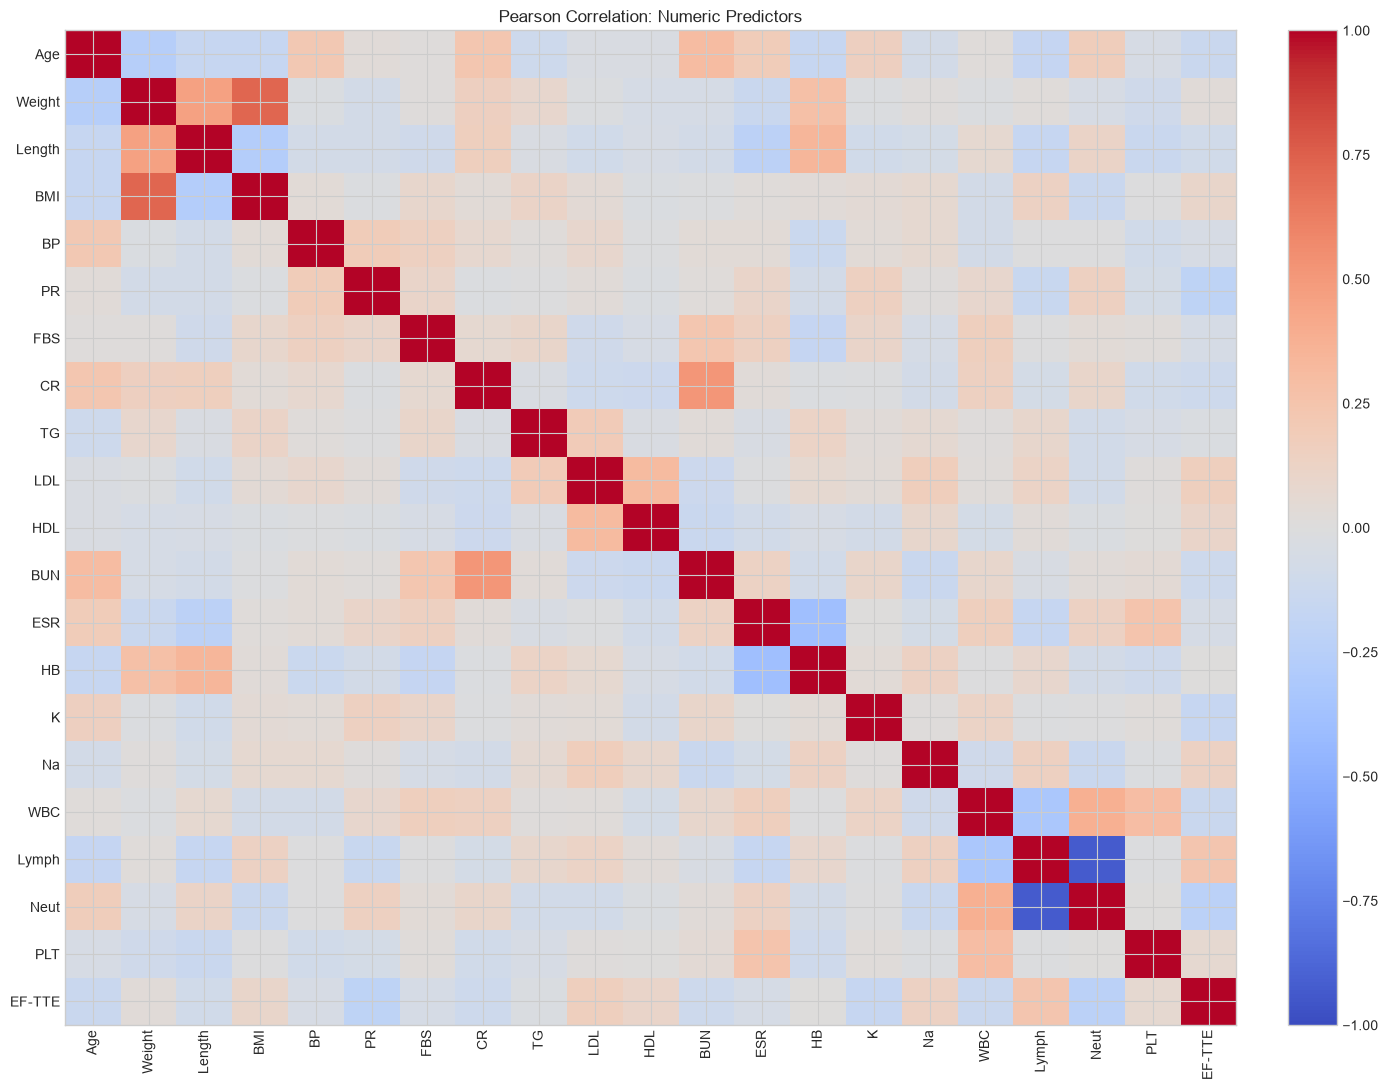

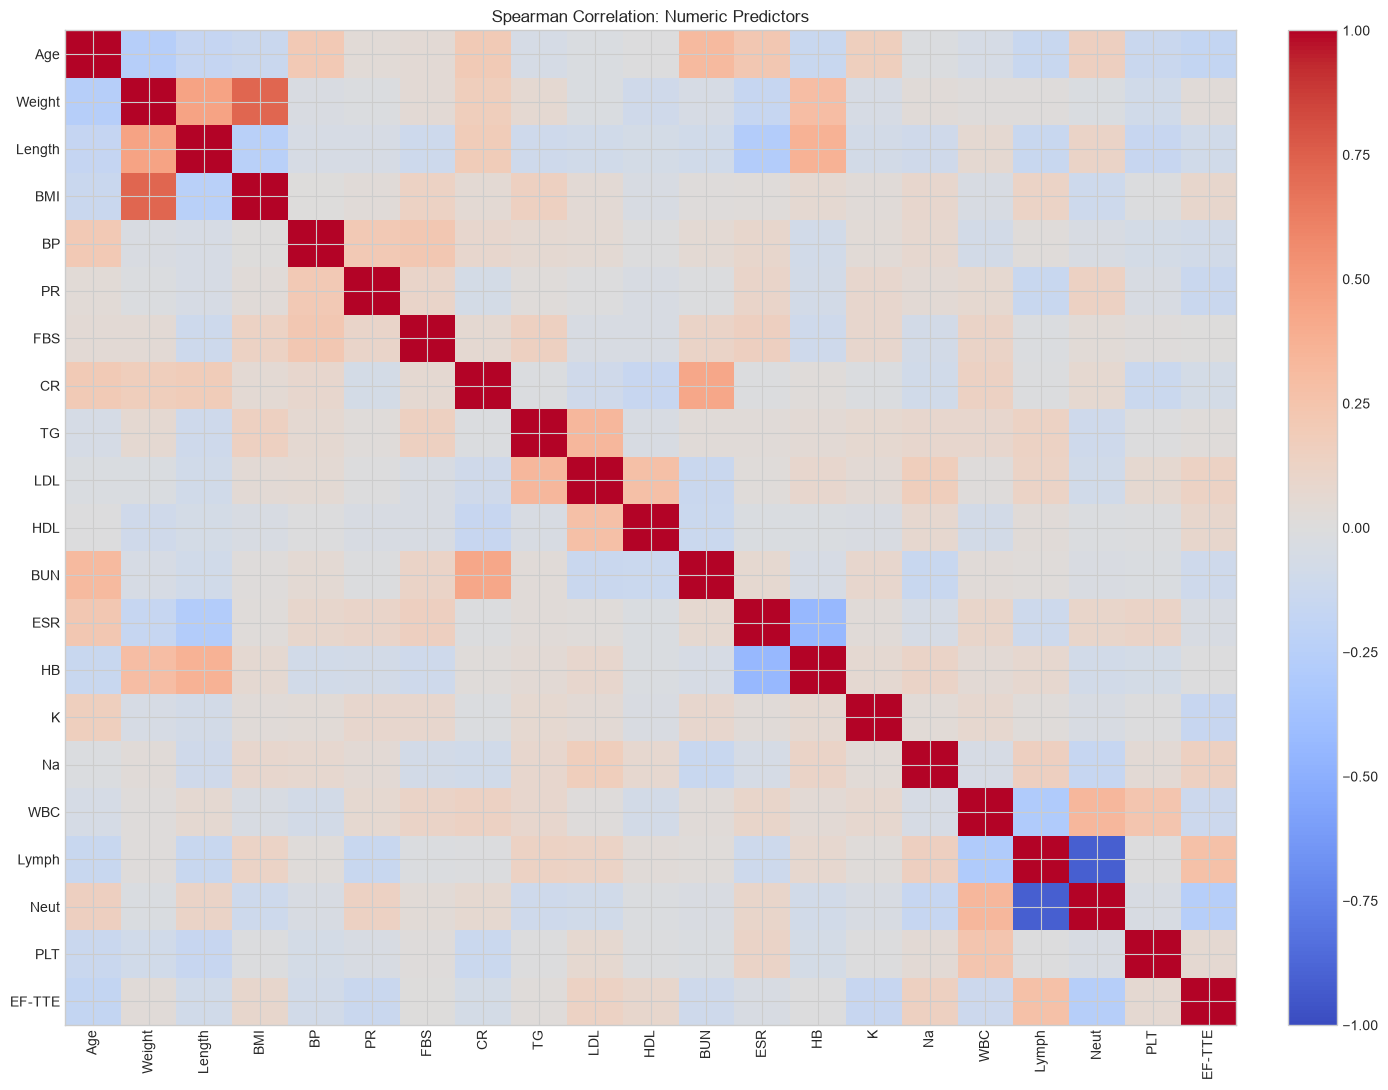

,feature_1,feature_2,pearson,spearman,possible_redundancy
0,Lymph,Neut,-0.9231,-0.9123,True


Saved ml\artifacts\metrics\eda\high_correlations.csv: (1, 5)


,feature,r_squared_from_other_numeric_features,vif
1,Weight,0.9897,97.3021
3,BMI,0.9879,82.3869
2,Length,0.9799,49.7879
18,Neut,0.8682,7.5865
17,Lymph,0.8655,7.4376
11,BUN,0.3901,1.6396
7,CR,0.3835,1.6221
16,WBC,0.3093,1.4479
13,HB,0.3028,1.4342
0,Age,0.2903,1.4091


In [6]:
pearson_corr = numeric_data.corr(method="pearson")
spearman_corr = numeric_data.corr(method="spearman")
plot_heatmap(pearson_corr, "Pearson Correlation: Numeric Predictors", figsize=(14, 11))
plot_heatmap(spearman_corr, "Spearman Correlation: Numeric Predictors", figsize=(14, 11))

high_corr_rows = []
for i, f1 in enumerate(numeric_features):
    for f2 in numeric_features[i + 1:]:
        pearson, spearman = pearson_corr.loc[f1, f2], spearman_corr.loc[f1, f2]
        if (pd.notna(pearson) and abs(pearson) >= 0.80) or (pd.notna(spearman) and abs(spearman) >= 0.80):
            high_corr_rows.append({"feature_1": f1, "feature_2": f2, "pearson": pearson, "spearman": spearman, "possible_redundancy": True})
high_correlations = pd.DataFrame(high_corr_rows) if high_corr_rows else pd.DataFrame(columns=["feature_1", "feature_2", "pearson", "spearman", "possible_redundancy"])
display(high_correlations)
save_table(high_correlations, "high_correlations.csv")

nonconstant = [c for c in numeric_features if numeric_data[c].nunique(dropna=True) > 1]
imputed_numeric = pd.DataFrame(SimpleImputer(strategy="median").fit_transform(numeric_data[nonconstant]), columns=nonconstant)
vif_rows = []
for feature in nonconstant:
    others = [c for c in nonconstant if c != feature]
    if len(others) < 2:
        continue
    model = LinearRegression().fit(imputed_numeric[others], imputed_numeric[feature])
    r2 = model.score(imputed_numeric[others], imputed_numeric[feature])
    vif_rows.append({"feature": feature, "r_squared_from_other_numeric_features": r2, "vif": np.inf if r2 >= 0.999999 else 1 / (1 - r2)})
vif_table = pd.DataFrame(vif_rows).sort_values("vif", ascending=False)
display(vif_table.head(20))

## 6. Feature to Target Exploratory Analysis

In [7]:
stat_rows = []
for target in TARGETS:
    target_series = y[target]
    for feature in numeric_features:
        x = numeric_data[feature]
        g0, g1 = x[target_series == 0].dropna(), x[target_series == 1].dropna()
        if len(g0) >= 3 and len(g1) >= 3 and x.nunique(dropna=True) > 1:
            u_stat, p_value = stats.mannwhitneyu(g0, g1, alternative="two-sided")
            effect = rank_biserial_from_u(u_stat, len(g0), len(g1))
            pb_r, pb_p = safe_point_biserial(x, target_series)
        else:
            u_stat = p_value = effect = pb_r = pb_p = np.nan
        stat_rows.append({
            "target": target, "feature": feature, "feature_type": "numeric", "test": "Mann-Whitney U",
            "statistic": u_stat, "raw_p_value": p_value, "effect_size_name": "rank_biserial",
            "effect_size": effect, "abs_effect_size": abs(effect) if pd.notna(effect) else np.nan,
            "point_biserial_r": pb_r, "point_biserial_p": pb_p,
        })
    for feature in categorical_features:
        cat = X[feature].astype("string").fillna("<MISSING>")
        contingency = pd.crosstab(cat, target_series).reindex(columns=[0, 1], fill_value=0)
        if contingency.shape[0] < 2 or contingency.shape[1] < 2:
            test_name, statistic, p_value, effect = "not_tested_constant_or_single_class", np.nan, np.nan, np.nan
        else:
            chi2, chi_p, _, expected = stats.chi2_contingency(contingency)
            if contingency.shape == (2, 2) and (expected < 5).any():
                statistic, p_value = stats.fisher_exact(contingency.to_numpy())
                test_name = "Fisher exact"
            else:
                statistic, p_value = chi2, chi_p
                test_name = "Chi-square"
            effect = cramers_v(contingency)
        stat_rows.append({
            "target": target, "feature": feature, "feature_type": "categorical_or_binary", "test": test_name,
            "statistic": statistic, "raw_p_value": p_value, "effect_size_name": "cramers_v",
            "effect_size": effect, "abs_effect_size": abs(effect) if pd.notna(effect) else np.nan,
            "point_biserial_r": np.nan, "point_biserial_p": np.nan,
        })

feature_target_statistics = pd.DataFrame(stat_rows)
feature_target_statistics["fdr_bh_p_value"] = feature_target_statistics.groupby("target", group_keys=False)["raw_p_value"].apply(benjamini_hochberg)
feature_target_statistics = feature_target_statistics.sort_values(["target", "abs_effect_size", "fdr_bh_p_value"], ascending=[True, False, True])
display(feature_target_statistics.groupby("target").head(12))
save_table(feature_target_statistics, "feature_target_statistics.csv")

,target,feature,feature_type,test,statistic,raw_p_value,effect_size_name,effect_size,abs_effect_size,point_biserial_r,point_biserial_p,fdr_bh_p_value
39,cad,Typical Chest Pain,categorical_or_binary,Chi-square,86.9360,0.0000,cramers_v,0.5356,0.5356,NaN,NaN,0.0000
0,cad,Age,numeric,Mann-Whitney U,5188.5000,0.0000,rank_biserial,-0.4478,0.4478,0.3572,0.0000,0.0000
42,cad,Atypical,categorical_or_binary,Chi-square,50.4420,0.0000,cramers_v,0.4080,0.4080,NaN,NaN,0.0000
20,cad,EF-TTE,numeric,Mann-Whitney U,12909.5000,0.0000,rank_biserial,0.3739,0.3739,-0.2340,0.0000,0.0000
53,cad,Region RWMA,categorical_or_binary,Chi-square,34.9010,0.0000,cramers_v,0.3394,0.3394,NaN,NaN,0.0000
4,cad,BP,numeric,Mann-Whitney U,6363.0000,0.0000,rank_biserial,-0.3228,0.3228,0.2378,0.0000,0.0001
6,cad,FBS,numeric,Mann-Whitney U,6553.5000,0.0000,rank_biserial,-0.3025,0.3025,0.2056,0.0003,0.0002
23,cad,HTN,categorical_or_binary,Chi-square,23.8134,0.0000,cramers_v,0.2803,0.2803,NaN,NaN,0.0000
12,cad,ESR,numeric,Mann-Whitney U,6879.5000,0.0003,rank_biserial,-0.2678,0.2678,0.1784,0.0018,0.0012
43,cad,Nonanginal,categorical_or_binary,Fisher exact,0.0802,0.0000,cramers_v,0.2579,0.2579,NaN,NaN,0.0001


Saved ml\artifacts\metrics\eda\feature_target_statistics.csv: (220, 12)


WindowsPath('C:/Users/samri/cod/git/IIT_Mandi/cardio-3d-ai/ml/artifacts/metrics/eda/feature_target_statistics.csv')

## 7. Mutual Information Exploration

In [8]:
parts = []
if numeric_features:
    parts.append(pd.DataFrame(SimpleImputer(strategy="median").fit_transform(numeric_data[numeric_features]), columns=numeric_features))
if categorical_features:
    cat_imputed = X[categorical_features].astype("string").fillna("<MISSING>")
    parts.append(pd.DataFrame(OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1).fit_transform(cat_imputed), columns=categorical_features))
X_mi = pd.concat(parts, axis=1)[numeric_features + categorical_features]
discrete_mask = [feature in categorical_features for feature in X_mi.columns]

mi_rows = []
for target in TARGETS:
    scores = mutual_info_classif(X_mi, y[target], discrete_features=discrete_mask, random_state=RANDOM_STATE, n_neighbors=3)
    mi_rows.extend({"target": target, "feature": feature, "mutual_information": float(score)} for feature, score in zip(X_mi.columns, scores))
mutual_information = pd.DataFrame(mi_rows).sort_values(["target", "mutual_information"], ascending=[True, False])
display(mutual_information.groupby("target").head(12))
save_table(mutual_information, "mutual_information.csv")

,target,feature,mutual_information
39,cad,Typical Chest Pain,0.1600
42,cad,Atypical,0.0829
53,cad,Region RWMA,0.0777
20,cad,EF-TTE,0.0767
0,cad,Age,0.0615
17,cad,Lymph,0.0423
23,cad,HTN,0.0411
22,cad,DM,0.0360
4,cad,BP,0.0356
43,cad,Nonanginal,0.0334


Saved ml\artifacts\metrics\eda\mutual_information.csv: (220, 3)


WindowsPath('C:/Users/samri/cod/git/IIT_Mandi/cardio-3d-ai/ml/artifacts/metrics/eda/mutual_information.csv')

## 8. Effect Size Summary

In [9]:
stats_best = feature_target_statistics.copy()
stats_best["abs_effect_rank"] = stats_best["abs_effect_size"].fillna(-1)
stats_best = stats_best.sort_values(["target", "feature", "abs_effect_rank"], ascending=[True, True, False]).drop_duplicates(["target", "feature"])
feature_signal_summary = stats_best.merge(mutual_information, on=["target", "feature"], how="left")
feature_signal_summary["exploratory_signal_label"] = feature_signal_summary.apply(
    lambda row: classify_signal(row["abs_effect_size"], row["fdr_bh_p_value"], row["mutual_information"]), axis=1
)
display(feature_signal_summary.sort_values(["target", "abs_effect_size", "mutual_information"], ascending=[True, False, False]).groupby("target").head(15))

,target,feature,feature_type,test,statistic,raw_p_value,effect_size_name,effect_size,abs_effect_size,point_biserial_r,point_biserial_p,fdr_bh_p_value,abs_effect_rank,mutual_information,exploratory_signal_label
50,cad,Typical Chest Pain,categorical_or_binary,Chi-square,86.9360,0.0000,cramers_v,0.5356,0.5356,NaN,NaN,0.0000,0.5356,0.1600,Strong exploratory signal
0,cad,Age,numeric,Mann-Whitney U,5188.5000,0.0000,rank_biserial,-0.4478,0.4478,0.3572,0.0000,0.0000,0.4478,0.0615,Strong exploratory signal
2,cad,Atypical,categorical_or_binary,Chi-square,50.4420,0.0000,cramers_v,0.4080,0.4080,NaN,NaN,0.0000,0.4080,0.0829,Strong exploratory signal
16,cad,EF-TTE,numeric,Mann-Whitney U,12909.5000,0.0000,rank_biserial,0.3739,0.3739,-0.2340,0.0000,0.0000,0.3739,0.0767,Strong exploratory signal
42,cad,Region RWMA,categorical_or_binary,Chi-square,34.9010,0.0000,cramers_v,0.3394,0.3394,NaN,NaN,0.0000,0.3394,0.0777,Strong exploratory signal
5,cad,BP,numeric,Mann-Whitney U,6363.0000,0.0000,rank_biserial,-0.3228,0.3228,0.2378,0.0000,0.0001,0.3228,0.0356,Strong exploratory signal
21,cad,FBS,numeric,Mann-Whitney U,6553.5000,0.0000,rank_biserial,-0.3025,0.3025,0.2056,0.0003,0.0002,0.3025,0.0328,Strong exploratory signal
26,cad,HTN,categorical_or_binary,Chi-square,23.8134,0.0000,cramers_v,0.2803,0.2803,NaN,NaN,0.0000,0.2803,0.0411,Moderate exploratory signal
17,cad,ESR,numeric,Mann-Whitney U,6879.5000,0.0003,rank_biserial,-0.2678,0.2678,0.1784,0.0018,0.0012,0.2678,0.0031,Moderate exploratory signal
36,cad,Nonanginal,categorical_or_binary,Fisher exact,0.0802,0.0000,cramers_v,0.2579,0.2579,NaN,NaN,0.0001,0.2579,0.0334,Moderate exploratory signal


## 9. Target-Specific Signal Comparison

In [10]:
comparison_rows = []
for feature in X.columns:
    row = {"feature": feature, "feature_type": "numeric" if feature in numeric_features else "categorical_or_binary"}
    for target in TARGETS:
        rec = feature_signal_summary[(feature_signal_summary["feature"] == feature) & (feature_signal_summary["target"] == target)].iloc[0]
        row[f"{target}_signal"] = rec["exploratory_signal_label"]
        row[f"{target}_abs_effect"] = rec["abs_effect_size"]
        row[f"{target}_fdr"] = rec["fdr_bh_p_value"]
        row[f"{target}_mi"] = rec["mutual_information"]
    comparison_rows.append(row)

score_map = {"Strong exploratory signal": 3, "Moderate exploratory signal": 2, "Weak exploratory signal": 1}
feature_signal_comparison = pd.DataFrame(comparison_rows)
feature_signal_comparison["max_signal_score"] = feature_signal_comparison[[f"{t}_signal" for t in TARGETS]].apply(lambda r: max(score_map.get(v, 0) for v in r), axis=1)
feature_signal_comparison = feature_signal_comparison.sort_values("max_signal_score", ascending=False)
display(feature_signal_comparison.head(20))
save_table(feature_signal_comparison, "feature_signal_comparison.csv")

,feature,feature_type,cad_signal,cad_abs_effect,cad_fdr,cad_mi,lad_signal,lad_abs_effect,lad_fdr,lad_mi,lcx_signal,lcx_abs_effect,lcx_fdr,lcx_mi,rca_signal,rca_abs_effect,rca_fdr,rca_mi,max_signal_score
0,Age,numeric,Strong exploratory signal,0.4478,0.0000,0.0615,Strong exploratory signal,0.3543,0.0000,0.0930,Strong exploratory signal,0.3617,0.0000,0.1102,Strong exploratory signal,0.2697,0.0009,0.0528,3
6,FBS,numeric,Strong exploratory signal,0.3025,0.0002,0.0328,Moderate exploratory signal,0.1632,0.0464,0.0492,Moderate exploratory signal,0.1820,0.0483,0.0000,Moderate exploratory signal,0.2078,0.0147,0.0390,3
4,BP,numeric,Strong exploratory signal,0.3228,0.0001,0.0356,Moderate exploratory signal,0.1916,0.0143,0.0212,Strong exploratory signal,0.2337,0.0090,0.0531,Weak exploratory signal,0.1229,0.2028,0.0000,3
17,Lymph,numeric,Moderate exploratory signal,0.1593,0.0765,0.0423,Strong exploratory signal,0.2177,0.0060,0.0530,Strong exploratory signal,0.0522,0.7248,0.0801,Moderate exploratory signal,0.2567,0.0016,0.0444,3
20,EF-TTE,numeric,Strong exploratory signal,0.3739,0.0000,0.0767,Strong exploratory signal,0.4169,0.0000,0.0539,Moderate exploratory signal,0.1745,0.0483,0.0000,Moderate exploratory signal,0.1563,0.0736,0.0000,3
12,ESR,numeric,Moderate exploratory signal,0.2678,0.0012,0.0031,Moderate exploratory signal,0.2428,0.0026,0.0222,Strong exploratory signal,0.1468,0.1391,0.0810,Moderate exploratory signal,0.2276,0.0069,0.0000,3
42,Atypical,categorical_or_binary,Strong exploratory signal,0.4080,0.0000,0.0829,Strong exploratory signal,0.3459,0.0000,0.0625,Moderate exploratory signal,0.1615,0.0443,0.0147,Moderate exploratory signal,0.2288,0.0009,0.0295,3
53,Region RWMA,categorical_or_binary,Strong exploratory signal,0.3394,0.0000,0.0777,Strong exploratory signal,0.3801,0.0000,0.0908,Weak exploratory signal,0.1383,0.4850,0.0094,Weak exploratory signal,0.0817,0.8647,0.0033,3
39,Typical Chest Pain,categorical_or_binary,Strong exploratory signal,0.5356,0.0000,0.1600,Strong exploratory signal,0.4528,0.0000,0.1092,Moderate exploratory signal,0.2860,0.0000,0.0440,Moderate exploratory signal,0.2843,0.0000,0.0436,3
18,Neut,numeric,Moderate exploratory signal,0.1581,0.0765,0.0000,Moderate exploratory signal,0.2178,0.0060,0.0000,Weak exploratory signal,0.0807,0.4890,0.0047,Moderate exploratory signal,0.2701,0.0009,0.0098,2


Saved ml\artifacts\metrics\eda\feature_signal_comparison.csv: (55, 19)


WindowsPath('C:/Users/samri/cod/git/IIT_Mandi/cardio-3d-ai/ml/artifacts/metrics/eda/feature_signal_comparison.csv')

## 10. Possible Data Quality Issues

In [11]:
quality_rows = []
for _, row in numeric_summary[numeric_summary["outlier_count_iqr"] > 0].iterrows():
    quality_rows.append({"issue_type": "extreme_values_iqr_flag", "feature": row["feature"], "details": f"{int(row['outlier_count_iqr'])} IQR outliers; do not remove automatically.", "manual_review_priority": "medium"})
for _, row in rare_categories.iterrows():
    quality_rows.append({"issue_type": "rare_category_lt_5_percent", "feature": row["feature"], "details": f"Category {row['category']} has {int(row['count'])} rows ({row['percent']:.2f}%).", "manual_review_priority": "medium"})
for _, row in near_constant_features.iterrows():
    quality_rows.append({"issue_type": "near_constant_feature", "feature": row["feature"], "details": f"Top category {row['top_category']} covers {row['top_category_percent']:.2f}% of rows.", "manual_review_priority": "medium"})
for _, row in high_correlations.iterrows():
    quality_rows.append({"issue_type": "high_numeric_correlation", "feature": f"{row['feature_1']} | {row['feature_2']}", "details": f"Pearson={row['pearson']:.3f}, Spearman={row['spearman']:.3f}.", "manual_review_priority": "medium"})

suspicious = feature_signal_summary[(feature_signal_summary["abs_effect_size"].fillna(0) >= 0.40) | (feature_signal_summary["fdr_bh_p_value"].fillna(1) <= 0.01) | (feature_signal_summary["mutual_information"].fillna(0) >= 0.08)]
for _, row in suspicious.iterrows():
    quality_rows.append({"issue_type": "suspiciously_target_associated_exploratory", "feature": row["feature"], "details": f"Target={row['target']}; effect={row['effect_size']:.3f}; FDR={row['fdr_bh_p_value']:.4g}; MI={row['mutual_information']:.4f}. Review, do not auto-select/drop.", "manual_review_priority": "medium"})

for feature in X.columns:
    matches = [term for term in ["cath", "angi", "sten", "diagnos", "cad", "lad", "lcx", "rca", "vessel"] if term in feature.lower()]
    if matches:
        quality_rows.append({"issue_type": "potential_name_based_leakage_candidate", "feature": feature, "details": f"Column name matched possible leakage terms: {matches}.", "manual_review_priority": "high"})
for feature in ["EF-TTE", "Region RWMA", "VHD"]:
    if feature in X.columns:
        quality_rows.append({"issue_type": "clinical_timing_review_needed", "feature": feature, "details": "Echo/imaging-derived predictor; confirm it is available before angiography/diagnosis in intended workflow.", "manual_review_priority": "high"})

data_quality_flags = pd.DataFrame(quality_rows).drop_duplicates().sort_values(["manual_review_priority", "issue_type", "feature"], ascending=[True, True, True])
display(data_quality_flags)
save_table(data_quality_flags, "data_quality_flags.csv")

,issue_type,feature,details,manual_review_priority
94,clinical_timing_review_needed,EF-TTE,Echo/imaging-derived predictor; confirm it is ...,high
95,clinical_timing_review_needed,Region RWMA,Echo/imaging-derived predictor; confirm it is ...,high
96,clinical_timing_review_needed,VHD,Echo/imaging-derived predictor; confirm it is ...,high
93,potential_name_based_leakage_candidate,Nonanginal,Column name matched possible leakage terms: ['...,high
0,extreme_values_iqr_flag,BMI,6 IQR outliers; do not remove automatically.,medium
1,extreme_values_iqr_flag,BP,9 IQR outliers; do not remove automatically.,medium
2,extreme_values_iqr_flag,BUN,17 IQR outliers; do not remove automatically.,medium
3,extreme_values_iqr_flag,CR,8 IQR outliers; do not remove automatically.,medium
4,extreme_values_iqr_flag,EF-TTE,15 IQR outliers; do not remove automatically.,medium
5,extreme_values_iqr_flag,ESR,13 IQR outliers; do not remove automatically.,medium


Saved ml\artifacts\metrics\eda\data_quality_flags.csv: (97, 4)


WindowsPath('C:/Users/samri/cod/git/IIT_Mandi/cardio-3d-ai/ml/artifacts/metrics/eda/data_quality_flags.csv')

## 11. Small-Data Modeling Recommendations

In [12]:
model_recommendations = pd.DataFrame([
    {"family": "Regularized Logistic Regression", "suitability": "Strong baseline for n=303; interpretable; regularization helps.", "preprocessing": "Median impute numeric, standardize numeric, impute categorical, one-hot encode inside CV folds.", "risk": "Linear boundary; calibration and threshold choice still need validation."},
    {"family": "Random Forest", "suitability": "Useful nonlinear baseline.", "preprocessing": "Impute values and one-hot encode categoricals inside folds.", "risk": "Can overfit and give unstable importances with correlated predictors."},
    {"family": "Extra Trees", "suitability": "Useful variance-reducing tree ensemble comparison.", "preprocessing": "Impute values and one-hot encode categoricals inside folds.", "risk": "Still overfits if unconstrained; importances can be biased."},
    {"family": "XGBoost", "suitability": "Strong tabular method if heavily regularized.", "preprocessing": "Impute and encode inside folds.", "risk": "High overfitting risk under aggressive tuning."},
    {"family": "LightGBM", "suitability": "Efficient gradient boosting.", "preprocessing": "Impute and encode inside folds.", "risk": "Leaf-wise growth can overfit small datasets unless constrained."},
    {"family": "CatBoost", "suitability": "Attractive for mixed categorical/numeric clinical data.", "preprocessing": "Use categorical feature names/indices; still keep all handling inside CV.", "risk": "Needs careful validation and calibration assessment."},
])
display(model_recommendations)

,family,suitability,preprocessing,risk
0,Regularized Logistic Regression,Strong baseline for n=303; interpretable; regu...,"Median impute numeric, standardize numeric, im...",Linear boundary; calibration and threshold cho...
1,Random Forest,Useful nonlinear baseline.,Impute values and one-hot encode categoricals ...,Can overfit and give unstable importances with...
2,Extra Trees,Useful variance-reducing tree ensemble compari...,Impute values and one-hot encode categoricals ...,Still overfits if unconstrained; importances c...
3,XGBoost,Strong tabular method if heavily regularized.,Impute and encode inside folds.,High overfitting risk under aggressive tuning.
4,LightGBM,Efficient gradient boosting.,Impute and encode inside folds.,Leaf-wise growth can overfit small datasets un...
5,CatBoost,Attractive for mixed categorical/numeric clini...,Use categorical feature names/indices; still k...,Needs careful validation and calibration asses...


## 12. Validation Strategy Design

In [13]:
validation_strategy = {
    "primary_cv": "Repeated Stratified K-Fold CV per target, such as 5 folds x 5 repeats if minority class counts remain adequate.",
    "holdout": "Consider a small untouched final holdout only if the team accepts reduced training/CV data; otherwise prefer repeated CV and external validation if available.",
    "four_target_setup": "Stratify separately for target-specific models. If one shared split is needed, inspect CAD/LAD/LCX/RCA class counts in every fold.",
    "leakage_control": "Fit preprocessing, imputation, scaling, encoding, supervised feature selection, and tuning only inside training folds.",
    "model_selection": "Use nested CV or an inner CV loop for substantial hyperparameter tuning.",
}
print(json.dumps(validation_strategy, indent=2))

{
  "primary_cv": "Repeated Stratified K-Fold CV per target, such as 5 folds x 5 repeats if minority class counts remain adequate.",
  "holdout": "Consider a small untouched final holdout only if the team accepts reduced training/CV data; otherwise prefer repeated CV and external validation if available.",
  "four_target_setup": "Stratify separately for target-specific models. If one shared split is needed, inspect CAD/LAD/LCX/RCA class counts in every fold.",
  "leakage_control": "Fit preprocessing, imputation, scaling, encoding, supervised feature selection, and tuning only inside training folds.",
  "model_selection": "Use nested CV or an inner CV loop for substantial hyperparameter tuning."
}


## 13. Metrics Plan

In [14]:
metrics_plan = pd.DataFrame([
    {"metric": "Accuracy", "reason": "Required, but insufficient under imbalance."},
    {"metric": "Precision", "reason": "False-positive burden."},
    {"metric": "Recall / Sensitivity", "reason": "Positive-case detection."},
    {"metric": "F1", "reason": "Precision/recall balance."},
    {"metric": "ROC-AUC", "reason": "Required ranking metric."},
    {"metric": "PR-AUC", "reason": "More informative with imbalance."},
    {"metric": "Specificity", "reason": "True-negative performance."},
    {"metric": "Balanced Accuracy", "reason": "Balances sensitivity and specificity."},
    {"metric": "MCC", "reason": "Robust binary metric under imbalance."},
    {"metric": "Brier Score", "reason": "Probability quality."},
    {"metric": "Calibration curve / ECE", "reason": "Needed because UI displays risk probabilities."},
])
display(metrics_plan)
print("Accuracy alone can hide poor positive-class detection.")
print("Probability calibration must be evaluated before showing CAD/stenosis probabilities in the UI.")

,metric,reason
0,Accuracy,"Required, but insufficient under imbalance."
1,Precision,False-positive burden.
2,Recall / Sensitivity,Positive-case detection.
3,F1,Precision/recall balance.
4,ROC-AUC,Required ranking metric.
5,PR-AUC,More informative with imbalance.
6,Specificity,True-negative performance.
7,Balanced Accuracy,Balances sensitivity and specificity.
8,MCC,Robust binary metric under imbalance.
9,Brier Score,Probability quality.


Accuracy alone can hide poor positive-class detection.
Probability calibration must be evaluated before showing CAD/stenosis probabilities in the UI.


## 14. Export EDA Reports

In [15]:
expected_exports = [
    "target_distribution.csv", "target_associations.csv", "numeric_summary.csv",
    "categorical_summary.csv", "high_correlations.csv", "feature_target_statistics.csv",
    "mutual_information.csv", "feature_signal_comparison.csv", "data_quality_flags.csv",
]
for filename in expected_exports:
    assert (EDA_DIR / filename).exists(), f"Missing export: {filename}"
assert not (EDA_DIR / "selected_features.csv").exists()
print("EDA exports verified:")
for filename in expected_exports:
    print(f"- {(EDA_DIR / filename).relative_to(PROJECT_ROOT)}")

EDA exports verified:
- ml\artifacts\metrics\eda\target_distribution.csv
- ml\artifacts\metrics\eda\target_associations.csv
- ml\artifacts\metrics\eda\numeric_summary.csv
- ml\artifacts\metrics\eda\categorical_summary.csv
- ml\artifacts\metrics\eda\high_correlations.csv
- ml\artifacts\metrics\eda\feature_target_statistics.csv
- ml\artifacts\metrics\eda\mutual_information.csv
- ml\artifacts\metrics\eda\feature_signal_comparison.csv
- ml\artifacts\metrics\eda\data_quality_flags.csv


## 15. Final Report

In [16]:
strongest_by_target = (
    feature_signal_summary.sort_values(["target", "abs_effect_size", "mutual_information"], ascending=[True, False, False])
    .groupby("target")
    .head(8)
    [["target", "feature", "feature_type", "test", "effect_size", "fdr_bh_p_value", "mutual_information", "exploratory_signal_label"]]
)
final_report = {
    "dataset_size": int(len(X)),
    "number_of_predictors": int(X.shape[1]),
    "numeric_predictors": len(numeric_features),
    "categorical_or_binary_predictors": len(categorical_features),
    "target_balance": target_distribution.to_dict("records"),
    "strongest_exploratory_relationships_per_target": strongest_by_target.to_dict("records"),
    "highly_correlated_predictors": high_correlations.to_dict("records"),
    "near_constant_features": near_constant_features.to_dict("records"),
    "rare_category_count": int(len(rare_categories)),
    "potential_leakage_concerns": data_quality_flags[data_quality_flags["issue_type"].str.contains("leakage|timing", case=False, regex=True)].to_dict("records"),
    "important_outlier_observations": numeric_summary.sort_values("outlier_count_iqr", ascending=False).head(10)[["feature", "outlier_count_iqr", "min", "max", "skewness"]].to_dict("records"),
    "recommended_model_families": model_recommendations["family"].tolist(),
    "recommended_cv_strategy": validation_strategy,
}
print("Concise EDA report:")
print(json.dumps(final_report, indent=2, default=str))
print("\\nNO FEATURES WERE SELECTED OR REMOVED USING FULL-DATASET TARGET INFORMATION.")

Concise EDA report:
{
  "dataset_size": 303,
  "number_of_predictors": 55,
  "numeric_predictors": 21,
  "categorical_or_binary_predictors": 34,
  "target_balance": [
    {
      "target": "cad",
      "negative_count": 87,
      "positive_count": 216,
      "negative_percent": 28.71287128712871,
      "positive_percent": 71.28712871287128,
      "imbalance_ratio_majority_to_minority": 2.4827586206896552
    },
    {
      "target": "lad",
      "negative_count": 126,
      "positive_count": 177,
      "negative_percent": 41.584158415841586,
      "positive_percent": 58.415841584158414,
      "imbalance_ratio_majority_to_minority": 1.4047619047619047
    },
    {
      "target": "lcx",
      "negative_count": 184,
      "positive_count": 119,
      "negative_percent": 60.726072607260726,
      "positive_percent": 39.273927392739274,
      "imbalance_ratio_majority_to_minority": 1.546218487394958
    },
    {
      "target": "rca",
      "negative_count": 189,
      "positive_count": 11